In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/content/drive/MyDrive/TA_SER')


FEATURES_ROOT    = PROJECT_ROOT / 'data' / 'processed' / 'features_v4'
LABEL_ENCODER_FP = PROJECT_ROOT / 'data' / 'processed' / 'label_encoder.json'
MODEL_DIR        = PROJECT_ROOT / 'saved_models' / 'v4'
REPORTS_DIR      = PROJECT_ROOT / 'reports'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE       = 32
MAX_EPOCHS       = 100
LEARNING_RATE    = 0.001
LABEL_SMOOTHING  = 0.1
L2_REG           = 0.0002
DROPOUT_CONV     = 0.25
DROPOUT_INTEGRATE= 0.35
DROPOUT_DENSE    = 0.5
PATIENCE_ES      = 15
PATIENCE_LR      = 7
LR_FACTOR        = 0.5
MIN_LR           = 1e-6

MODEL_NAME       = 'model_B'
BRANCH_FILTERS   = 64
BRANCH_KERNELS   = [3, 5, 7]
BRANCH_DILATIONS = [1, 1, 1]
INTEGRATE_FILTERS= 128
INTEGRATE_KERNEL = 3
DENSE_UNITS      = 128

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_SHAPE = (188, 40)
NUM_CLASSES = 4

print(f'TF version: {tf.__version__}')
print(f'Model name: {MODEL_NAME}')
print(f'Branch kernels  : {BRANCH_KERNELS}')
print(f'Branch dilations: {BRANCH_DILATIONS}  (ALL=1, NO dilation)')


Mounted at /content/drive
TF version: 2.19.0
Model name: model_B
Branch kernels  : [3, 5, 7]
Branch dilations: [1, 1, 1]  (ALL=1, NO dilation)


In [ ]:
with open(LABEL_ENCODER_FP, 'r') as f:
    label_enc = json.load(f)

LABEL_TO_INT  = label_enc['label_to_int']
INT_TO_LABEL  = {int(k): v for k, v in label_enc['int_to_label'].items()}
TARGET_LABELS = label_enc['target_labels']

print(f'Target labels: {TARGET_LABELS}')


Target labels: ['angry', 'happy', 'neutral', 'sad']


In [ ]:
X_train = np.load(FEATURES_ROOT / 'train' / 'X_train.npy')
y_train = np.load(FEATURES_ROOT / 'train' / 'y_train.npy')
sources_train = np.load(FEATURES_ROOT / 'train' / 'sources_train.npy', allow_pickle=True)
y_train_oh = to_categorical(y_train, num_classes=NUM_CLASSES)

print(f'X_train: {X_train.shape}  y_train_oh: {y_train_oh.shape}')

val_per_source = {}
for src in ['ravdess', 'emodb', 'tess', 'savee']:
    X_v = np.load(FEATURES_ROOT / 'val' / f'X_val_{src}.npy')
    y_v = np.load(FEATURES_ROOT / 'val' / f'y_val_{src}.npy')
    val_per_source[src] = {
        'X': X_v,
        'y': y_v,
        'y_oh': to_categorical(y_v, num_classes=NUM_CLASSES)
    }
    print(f'  val_{src}: X={X_v.shape}  y={y_v.shape}')

X_val_combined = np.load(FEATURES_ROOT / 'val' / 'X_val_combined.npy')
y_val_combined = np.load(FEATURES_ROOT / 'val' / 'y_val_combined.npy')
y_val_combined_oh = to_categorical(y_val_combined, num_classes=NUM_CLASSES)
print(f'\n X_val_combined: {X_val_combined.shape}')


X_train: (9312, 188, 40)  y_train_oh: (9312, 4)
  val_ravdess: X=(67, 188, 40)  y=(67,)
  val_emodb: X=(34, 188, 40)  y=(34,)
  val_tess: X=(160, 188, 40)  y=(160,)
  val_savee: X=(30, 188, 40)  y=(30,)

 X_val_combined: (291, 188, 40)


In [ ]:
def build_branch(x, filters, kernel_size, dilation_rate, name_prefix, use_causal=False):

    padding = 'causal' if use_causal else 'same'
    x = layers.Conv1D(
        filters, kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding=padding,
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name=f'{name_prefix}_conv'
    )(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn')(x)
    x = layers.Activation('relu', name=f'{name_prefix}_relu')(x)
    x = layers.Dropout(DROPOUT_CONV, name=f'{name_prefix}_drop')(x)
    x = layers.MaxPooling1D(pool_size=2, name=f'{name_prefix}_pool')(x)
    return x


def build_model_B(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):

    inputs = layers.Input(shape=input_shape, name='input')

    branches = []
    for i, (k, d) in enumerate(zip(BRANCH_KERNELS, BRANCH_DILATIONS)):
        branch = build_branch(
            inputs,
            filters=BRANCH_FILTERS,
            kernel_size=k,
            dilation_rate=d,
            name_prefix=f'branch{i+1}_k{k}_d{d}',
            use_causal=False
        )
        branches.append(branch)

    x = layers.Concatenate(axis=-1, name='concat')(branches)

    x = layers.Conv1D(
        INTEGRATE_FILTERS, kernel_size=INTEGRATE_KERNEL, padding='same',
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name='integrate_conv'
    )(x)
    x = layers.BatchNormalization(name='integrate_bn')(x)
    x = layers.Activation('relu', name='integrate_relu')(x)
    x = layers.Dropout(DROPOUT_INTEGRATE, name='integrate_drop')(x)

    x = layers.GlobalAveragePooling1D(name='gap')(x)

    x = layers.Dense(
        DENSE_UNITS, activation='relu',
        kernel_regularizer=keras.regularizers.l2(L2_REG), name='dense1'
    )(x)
    x = layers.Dropout(DROPOUT_DENSE, name='drop_dense')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name=MODEL_NAME)


model = build_model_B()
model.summary()
total_params = model.count_params()
print(f'\n Total params: {total_params:,}')


Model: "model_B"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 188, 40)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_conv  │ (None, 188, 64)   │      7,744 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d1_conv  │ (None, 188, 64)   │     12,864 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d1_conv  │ (None, 188, 64)   │     17,984 │ input[0][0]       │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_bn    │ (None, 188, 64)   │        256 │ branch1_k3_d1_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d1_bn    │ (None, 188, 64)   │        256 │ branch2_k5_d1_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d1_bn    │ (None, 188, 64)   │        256 │ branch3_k7_d1_co… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_relu  │ (None, 188, 64)   │          0 │ branch1_k3_d1_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d1_relu  │ (None, 188, 64)   │          0 │ branch2_k5_d1_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d1_relu  │ (None, 188, 64)   │          0 │ branch3_k7_d1_bn… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_drop  │ (None, 188, 64)   │          0 │ branch1_k3_d1_re… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d1_drop  │ (None, 188, 64)   │          0 │ branch2_k5_d1_re… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d1_drop  │ (None, 188, 64)   │          0 │ branch3_k7_d1_re… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch1_k3_d1_pool  │ (None, 94, 64)    │          0 │ branch1_k3_d1_dr… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k5_d1_pool  │ (None, 94, 64)    │          0 │ branch2_k5_d1_dr… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch3_k7_d1_pool  │ (None, 94, 64)    │          0 │ branch3_k7_d1_dr… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 94, 192)   │          0 │ branch1_k3_d1_po… │
│ (Concatenate)       │                   │            │ branch2_k5_d1_po

 Total params: 130,756 (510.77 KB)

 Trainable params: 130,116 (508.27 KB)

 Non-trainable params: 640 (2.50 KB)


 Total params: 130,756


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)
print(f' Model compiled')


 Model compiled


In [ ]:
class PerSourceValAccCallback(Callback):

    def __init__(self, val_per_source):
        super().__init__()
        self.val_per_source = val_per_source
        self.history_per_source = {src: [] for src in val_per_source.keys()}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        for src, data in self.val_per_source.items():
            y_pred = self.model.predict(data['X'], verbose=0)
            y_pred_class = np.argmax(y_pred, axis=1)
            acc = float(np.mean(y_pred_class == data['y']))
            self.history_per_source[src].append(acc)

            logs[f'val_acc_{src}'] = acc


per_source_callback = PerSourceValAccCallback(val_per_source)


In [ ]:
checkpoint_path = MODEL_DIR / f'{MODEL_NAME}_best.keras'

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE_ES,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        patience=PATIENCE_LR,
        factor=LR_FACTOR,
        min_lr=MIN_LR,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=0
    ),
    per_source_callback
]

print(f'Callbacks:')
print(f'  - EarlyStopping (val_loss, patience={PATIENCE_ES})')
print(f'  - ReduceLROnPlateau (val_loss, patience={PATIENCE_LR})')
print(f'  - ModelCheckpoint → {checkpoint_path.name} (.keras format)')
print(f'  - PerSourceValAccCallback (4 sources)')


Callbacks:
  - EarlyStopping (val_loss, patience=15)
  - ReduceLROnPlateau (val_loss, patience=7)
  - ModelCheckpoint → model_B_best.keras (.keras format)
  - PerSourceValAccCallback (4 sources)


In [ ]:
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val_combined, y_val_combined_oh),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

print(f'\n Training complete')
print(f'  Final epoch: {len(history.history["loss"])}')
print(f'  Best val_loss: {min(history.history["val_loss"]):.4f}')
print(f'  Best val_acc: {max(history.history["val_accuracy"]):.4f}')


Epoch 1/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.7460 - loss: 0.9092 - val_accuracy: 0.8454 - val_loss: 0.7419 - learning_rate: 0.0010 - val_acc_ravdess: 0.6119 - val_acc_emodb: 0.6765 - val_acc_tess: 1.0000 - val_acc_savee: 0.7333
Epoch 2/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8382 - loss: 0.7577 - val_accuracy: 0.8625 - val_loss: 0.6973 - learning_rate: 0.0010 - val_acc_ravdess: 0.7015 - val_acc_emodb: 0.7647 - val_acc_tess: 1.0000 - val_acc_savee: 0.6000
Epoch 3/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8701 - loss: 0.6982 - val_accuracy: 0.8832 - val_loss: 0.6737 - learning_rate: 0.0010 - val_acc_ravdess: 0.7164 - val_acc_emodb: 0.7647 - val_acc_tess: 1.0000 - val_acc_savee: 0.7667
Epoch 4/100
291/291 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8923 - loss: 0.6642 - val_accuracy: 0.8797 - val_loss: 0.6762 - learning_rate: 0.0010 - val_acc_ravdess: 0.6716 - val_acc_emodb: 0.7353 - val_acc_tess: 1.0000 - val_acc_savee: 0.866

In [ ]:
full_history = dict(history.history)
full_history['val_acc_per_source'] = per_source_callback.history_per_source

def sanitize(obj):
    if isinstance(obj, dict):
        return {k: sanitize(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sanitize(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

full_history_clean = sanitize(full_history)

full_history_clean['_metadata'] = {
    'model_name': MODEL_NAME,
    'input_shape': list(INPUT_SHAPE),
    'num_classes': NUM_CLASSES,
    'total_params': int(total_params),
    'config': {
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'label_smoothing': LABEL_SMOOTHING,
        'l2_reg': L2_REG,
        'dropout_conv': DROPOUT_CONV,
        'dropout_integrate': DROPOUT_INTEGRATE,
        'dropout_dense': DROPOUT_DENSE,
        'branch_filters': BRANCH_FILTERS,
        'branch_kernels': BRANCH_KERNELS,
        'branch_dilations': BRANCH_DILATIONS,
        'integrate_filters': INTEGRATE_FILTERS,
    },
    'epochs_trained': len(history.history['loss']),
    'best_val_loss': float(min(history.history['val_loss'])),
    'best_val_acc': float(max(history.history['val_accuracy'])),
}

history_path = MODEL_DIR / f'history_{MODEL_NAME[-1]}.json'
with open(history_path, 'w') as f:
    json.dump(full_history_clean, f, indent=2)

print(f' History saved: {history_path}')


 History saved: /content/drive/MyDrive/TA_SER/saved_models/v4/history_B.json


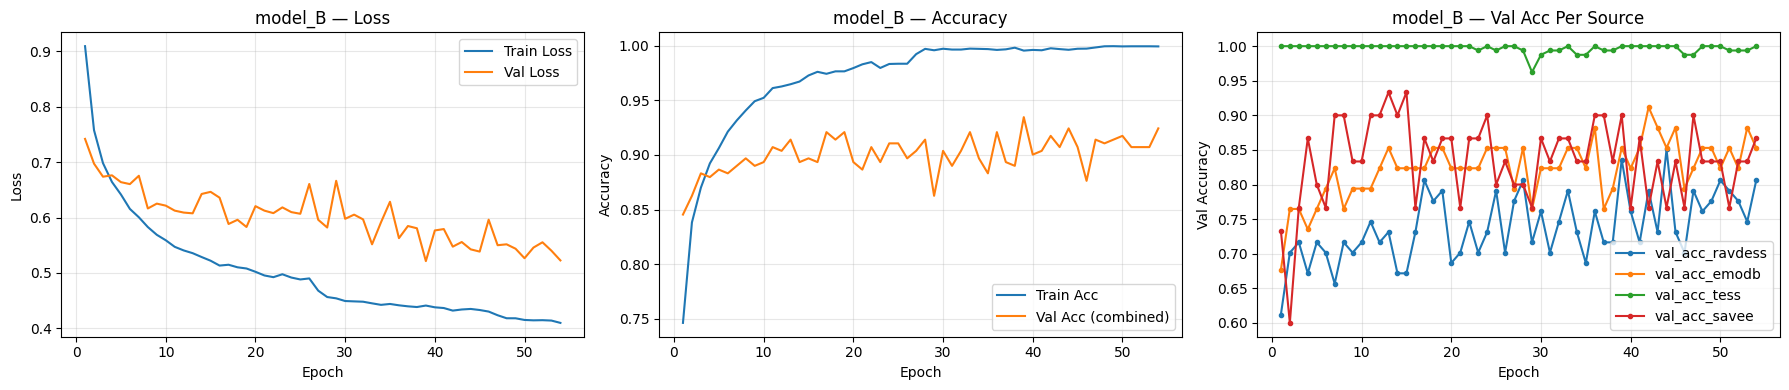

 Plot saved: /content/drive/MyDrive/TA_SER/reports/training_curves_B.png


In [ ]:
epochs = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history.history['loss'], label='Train Loss')
axes[0].plot(epochs, history.history['val_loss'], label='Val Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history.history['accuracy'], label='Train Acc')
axes[1].plot(epochs, history.history['val_accuracy'], label='Val Acc (combined)')
axes[1].set_title(f'{MODEL_NAME} — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

for src, acc_list in per_source_callback.history_per_source.items():
    axes[2].plot(range(1, len(acc_list)+1), acc_list, label=f'val_acc_{src}', marker='.')
axes[2].set_title(f'{MODEL_NAME} — Val Acc Per Source')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Val Accuracy')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
curves_path = REPORTS_DIR / f'training_curves_{MODEL_NAME[-1]}.png'
plt.savefig(curves_path, dpi=100, bbox_inches='tight')
plt.show()

print(f' Plot saved: {curves_path}')


In [ ]:
print('=' * 60)
print(f'MODEL B (Multi-Branch NO Dilation) — Training Summary')
print('=' * 60)
print(f'Total params          : {total_params:,}')
print(f'Epochs trained        : {len(history.history["loss"])}')
print(f'Best val_loss         : {min(history.history["val_loss"]):.4f}')
print(f'Best val_acc (combined): {max(history.history["val_accuracy"]):.4f}')
print()
print('Final val_acc per source:')
for src, acc_list in per_source_callback.history_per_source.items():
    print(f'  {src:8s}: last={acc_list[-1]:.3f}  best={max(acc_list):.3f}')
print()
print(f'Checkpoint: {checkpoint_path}')
print(f'History   : {history_path}')
print(f'Plot      : {curves_path}')


MODEL B (Multi-Branch NO Dilation) — Training Summary
Total params          : 130,756
Epochs trained        : 54
Best val_loss         : 0.5214
Best val_acc (combined): 0.9347

Final val_acc per source:
  ravdess : last=0.806  best=0.851
  emodb   : last=0.853  best=0.912
  tess    : last=1.000  best=1.000
  savee   : last=0.867  best=0.933

Checkpoint: /content/drive/MyDrive/TA_SER/saved_models/v4/model_B_best.keras
History   : /content/drive/MyDrive/TA_SER/saved_models/v4/history_B.json
Plot      : /content/drive/MyDrive/TA_SER/reports/training_curves_B.png
